# Notebook 2: Diagnostic Business Analytics

## 1. Executive Summary & Diagnostic Framework
Following the successful consolidation of our transactional database in Notebook 1, this notebook executes a deep-dive diagnostic analysis into the commercial health of ITB.

Our diagnostic framework is designed to test critical business assumptions and uncover the underlying drivers of ITB's financial performance across 2022, 2023, and 2024. Specifically, we will investigate:
1. **The Growth Paradox:** Why overall financial metrics (revenue and profit) appear strong, while the customer foundation seems to be collapsing.
2. **The "Bait Strategy" Failure:** Why the historical funnel strategy (using low-cost Products A & B to acquire and transition customers to core Product C) has plummeted in efficiency.
3. **The Customer Retention Crisis:** Quantifying the "leaky bucket" problem through Cohort analysis and Churn profiling.
4. **Geographical & Demographic Opportunities:** Mapping where core Product C is under-performing or holding untapped potential.
5. **Cost Optimization Simulations:** Simulating financial outcomes of shifting from physical retail channels to high-margin online models.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting styles for professional visualization
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False

# Path resolution to load the processed master file
processed_data_path = '../data/processed/master_df.csv'
if not os.path.exists(processed_data_path):
    processed_data_path = 'data/processed/master_df.csv'

# Load the Consolidated Master Data
try:
    df_master = pd.read_csv(processed_data_path, low_memory=False)
    # Ensure datetime parsing is preserved
    df_master['order_date'] = pd.to_datetime(df_master['order_date'])
    df_master['dob'] = pd.to_datetime(df_master['dob'])
    print(f"Successfully loaded Consolidated Master Data. Shape: {df_master.shape}")
except FileNotFoundError as e:
    print(f"Error: {e}. Please run Notebook 1 first to generate the processed master file.")

Successfully loaded Consolidated Master Data. Shape: (2049263, 24)


## 2. The Growth Paradox: Financial Vitality vs. Customer Base Decay

ITB's financial indicators show remarkable growth over the observed window. However, relying solely on top-line figures creates a dangerous blind spot. 

In this section, we analyze the structural health of our revenue model by examining the mismatch between **financial growth** and **customer base vitality**. We define:
* **Financial Metrics:** Annual Revenue and Profit trends.
* **Customer Base Vitality:** The count of unique active customers transacting each year, and the year-over-year (YoY) growth of this customer base.

In [29]:
print("--- Calculating Overall Financial & Customer Trends ---")

# 1. Total Financial Metrics per Year (only from successfully delivered orders)
df_delivered = df_master[df_master['order_status'] == 'successfully delivered'].copy()

financials_yearly = df_delivered.groupby('year').agg(
    annual_revenue=('product_price', 'sum'),
    annual_cost=('product_cost', 'sum')
).reset_index()

# Calculate Net Profit & Profit Margin
financials_yearly['net_profit'] = financials_yearly['annual_revenue'] - financials_yearly['annual_cost']
financials_yearly['net_profit_margin_rate (%)'] = (financials_yearly['net_profit'] / financials_yearly['annual_revenue']) * 100


# 2. Total Unique Active Customers per Year (from successful transactions)
customers_yearly = df_delivered.groupby('year')['customer_id'].nunique().reset_index()
customers_yearly.rename(columns={'customer_id': 'active_customer_count'}, inplace=True)

# Calculate Year-over-Year (YoY) growth rate of active customer base
customers_yearly['customer_growth_yoy (%)'] = customers_yearly['active_customer_count'].pct_change() * 100


# 3. Merge Financials and Customer Base data for cross-evaluation
paradox_summary = pd.merge(financials_yearly, customers_yearly, on='year')

print("\nITB Performance Paradox Summary (2022 - 2024):")
display(paradox_summary.style.format({
    'annual_revenue': '{:,.0f} VND',
    'annual_cost': '{:,.0f} VND',
    'net_profit': '{:,.0f} VND',
    'net_profit_margin_rate (%)': '{:.2f}%',
    'active_customer_count': '{:,.0f}',
    'customer_growth_yoy (%)': '{:.2f}%'
}))

--- Calculating Overall Financial & Customer Trends ---

ITB Performance Paradox Summary (2022 - 2024):


,year,annual_revenue,annual_cost,net_profit,net_profit_margin_rate (%),active_customer_count,customer_growth_yoy (%)
0,2022,"7,213,973,112,382 VND","6,515,081,432,077 VND","698,891,680,305 VND",9.69%,"406,738",nan%
1,2023,"7,097,189,459,768 VND","6,315,035,490,782 VND","782,153,968,986 VND",11.02%,"363,732",-10.57%
2,2024,"8,746,644,109,265 VND","7,986,352,139,155 VND","760,291,970,111 VND",8.69%,"383,421",5.41%


- **Financially**: Revenue surged from **7.21 trillion VND (2022)** to **8.75 trillion VND (2024)** (an increase of over 21%).

- **Customer Health-wise**: The number of active customers actually dropped sharply from **406,738 (2022)** to **363,732 (2023)** (a **-10.57%** decrease), before recovering slightly in 2024 but still failing to reach the 2022 level.

*Technical note*: The profit level at this stage is **Gross Profit** because we are only taking Revenue minus product_cost, excluding variable costs and operating fixed costs of physical channels (which will be addressed later). However, even at the gross level, the decline in the active customer base is a highly dangerous early warning signal.

## 3. Evaluating the "Bait Strategy" Funnel (A/B -> C Conversion)

ITB's core commercial hypothesis was that low-cost, mass-market Products A & B would serve as "bait" (acquisition hooks) to attract a large volume of new customers, who would then be easily funneled and upgraded into purchasing our high-margin, premium Product C over time.

To test this hypothesis, we perform a chronological funnel conversion analysis:
1. **Identify the Acquisition Cohort:** For each unique customer, determine their first-ever purchase date and the corresponding product profile.
2. **Isolate Bait-Acquired Customers:** Filter customers whose first purchase was either Product A or Product B.
3. **Track Upgrade to Product C:** For this cohort of bait-acquired customers, verify if they purchased Product C on any subsequent date (`first_c_date > first_bait_date`).
4. **Calculate Yearly Conversion Rates:** Group these metrics by the customer's acquisition year to evaluate the efficiency of the funnel over time.

In [30]:
print("--- Analyzing Bait-to-Core Conversion Rates Over Time ---")

# Step 1: Find the first transaction date for each unique customer (Acquisition Date)
df_first_purchases = df_delivered.sort_values(by=['customer_id', 'order_date']).drop_duplicates(subset=['customer_id'], keep='first').copy()
df_first_purchases.rename(columns={'order_date': 'first_purchase_date', 'product_profile': 'first_product_purchased'}, inplace=True)
df_first_purchases['acquisition_year'] = df_first_purchases['first_purchase_date'].dt.year

# Step 2: Isolate customers acquired via bait products (Product A or B)
df_bait_acquired = df_first_purchases[df_first_purchases['first_product_purchased'].isin(['product_A', 'product_B'])][['customer_id', 'first_purchase_date', 'acquisition_year']].copy()
total_bait_acquired_by_year = df_bait_acquired.groupby('acquisition_year')['customer_id'].nunique().reset_index()
total_bait_acquired_by_year.rename(columns={'customer_id': 'bait_acquired_customer_count'}, inplace=True)


# Step 3: Find the first purchase date of Product C for all customers
df_c_purchases = df_delivered[df_delivered['product_profile'] == 'product_C'].copy()
df_first_c_dates = df_c_purchases.groupby('customer_id')['order_date'].min().reset_index()
df_first_c_dates.rename(columns={'order_date': 'first_c_purchase_date'}, inplace=True)


# Step 4: Merge bait cohorts with Product C purchase records
df_conversion_merged = pd.merge(df_bait_acquired, df_first_c_dates, on='customer_id', how='inner')

# Identify successful conversions where Product C was purchased AFTER the bait product
df_successful_conversions = df_conversion_merged[df_conversion_merged['first_c_purchase_date'] > df_conversion_merged['first_purchase_date']].copy()
converted_customers_by_year = df_successful_conversions.groupby('acquisition_year')['customer_id'].nunique().reset_index()
converted_customers_by_year.rename(columns={'customer_id': 'successfully_converted_count'}, inplace=True)


# Step 5: Consolidate and calculate annual conversion rates
funnel_conversion_summary = pd.merge(total_bait_acquired_by_year, converted_customers_by_year, on='acquisition_year', how='left').fillna(0)
funnel_conversion_summary['conversion_rate (%)'] = (funnel_conversion_summary['successfully_converted_count'] / funnel_conversion_summary['bait_acquired_customer_count']) * 100

print("\nBait Funnel (A/B -> C) Conversion Performance:")
display(funnel_conversion_summary.style.format({
    'bait_acquired_customer_count': '{:,.0f}',
    'successfully_converted_count': '{:,.0f}',
    'conversion_rate (%)': '{:.2f}%'
}))

--- Analyzing Bait-to-Core Conversion Rates Over Time ---

Bait Funnel (A/B -> C) Conversion Performance:


,acquisition_year,bait_acquired_customer_count,successfully_converted_count,conversion_rate (%)
0,2022,"372,706","49,582",13.30%
1,2023,"192,826","15,549",8.06%
2,2024,"152,204","3,892",2.56%


In [31]:
print("--- Analyzing Bait-to-Core Conversion Rates Over Time ---")

# Step 1: Find the first transaction date for each unique customer (Acquisition Date)
df_first_purchases = df_delivered.sort_values(by=['customer_id', 'order_date']).drop_duplicates(subset=['customer_id'], keep='first').copy()
df_first_purchases.rename(columns={'order_date': 'first_purchase_date', 'product_profile': 'first_product_purchased'}, inplace=True)
df_first_purchases['acquisition_year'] = df_first_purchases['first_purchase_date'].dt.year

# Step 2: Isolate customers acquired via bait products (Product A or B)
df_bait_acquired = df_first_purchases[df_first_purchases['first_product_purchased'].isin(['product_A', 'product_B'])][['customer_id', 'first_purchase_date', 'acquisition_year']].copy()
total_bait_acquired_by_year = df_bait_acquired.groupby('acquisition_year')['customer_id'].nunique().reset_index()
total_bait_acquired_by_year.rename(columns={'customer_id': 'bait_acquired_customer_count'}, inplace=True)


# Step 3: Find the first purchase date of Product C for all customers
df_c_purchases = df_delivered[df_delivered['product_profile'] == 'product_C'].copy()
df_first_c_dates = df_c_purchases.groupby('customer_id')['order_date'].min().reset_index()
df_first_c_dates.rename(columns={'order_date': 'first_c_purchase_date'}, inplace=True)


# Step 4: Merge bait cohorts with Product C purchase records
df_conversion_merged = pd.merge(df_bait_acquired, df_first_c_dates, on='customer_id', how='inner')

# Identify successful conversions where Product C was purchased AFTER the bait product
df_successful_conversions = df_conversion_merged[df_conversion_merged['first_c_purchase_date'] > df_conversion_merged['first_purchase_date']].copy()
converted_customers_by_year = df_successful_conversions.groupby('acquisition_year')['customer_id'].nunique().reset_index()
converted_customers_by_year.rename(columns={'customer_id': 'successfully_converted_count'}, inplace=True)


# Step 5: Consolidate and calculate annual conversion rates
funnel_conversion_summary = pd.merge(total_bait_acquired_by_year, converted_customers_by_year, on='acquisition_year', how='left').fillna(0)
funnel_conversion_summary['conversion_rate (%)'] = (funnel_conversion_summary['successfully_converted_count'] / funnel_conversion_summary['bait_acquired_customer_count']) * 100

print("\nBait Funnel (A/B -> C) Conversion Performance:")
display(funnel_conversion_summary.style.format({
    'bait_acquired_customer_count': '{:,.0f}',
    'successfully_converted_count': '{:,.0f}',
    'conversion_rate (%)': '{:.2f}%'
}))

--- Analyzing Bait-to-Core Conversion Rates Over Time ---

Bait Funnel (A/B -> C) Conversion Performance:


,acquisition_year,bait_acquired_customer_count,successfully_converted_count,conversion_rate (%)
0,2022,"372,706","49,582",13.30%
1,2023,"192,826","15,549",8.06%
2,2024,"152,204","3,892",2.56%


### 3.1. Visualizing the Funnel Collapse

The data reveals a critical "double-whammy" failure in ITB's historical funnel model:
1. **Shrinking Funnel Mouth:** The volume of new users acquired via Products A & B has contracted by **59%** in just two years.
2. **Funnel Leakage:** The conversion rate has dropped by more than **80%** (from 13.30% down to 2.56%). 

To present these findings to the executive board, we build a highly polished dual-axis visualization:
*   **Left Axis (Bar Chart):** Compares the volume of total acquired bait customers vs. those who successfully upgraded to Product C.
*   **Right Axis (Line Chart):** Illustrates the plummeting conversion rate trend line.

*Note: The generated chart will be automatically saved to `assets/charts/` for seamless integration into our portfolio README.*

Polished funnel chart successfully exported to: '../assets/charts/bait_funnel_conversion.png'


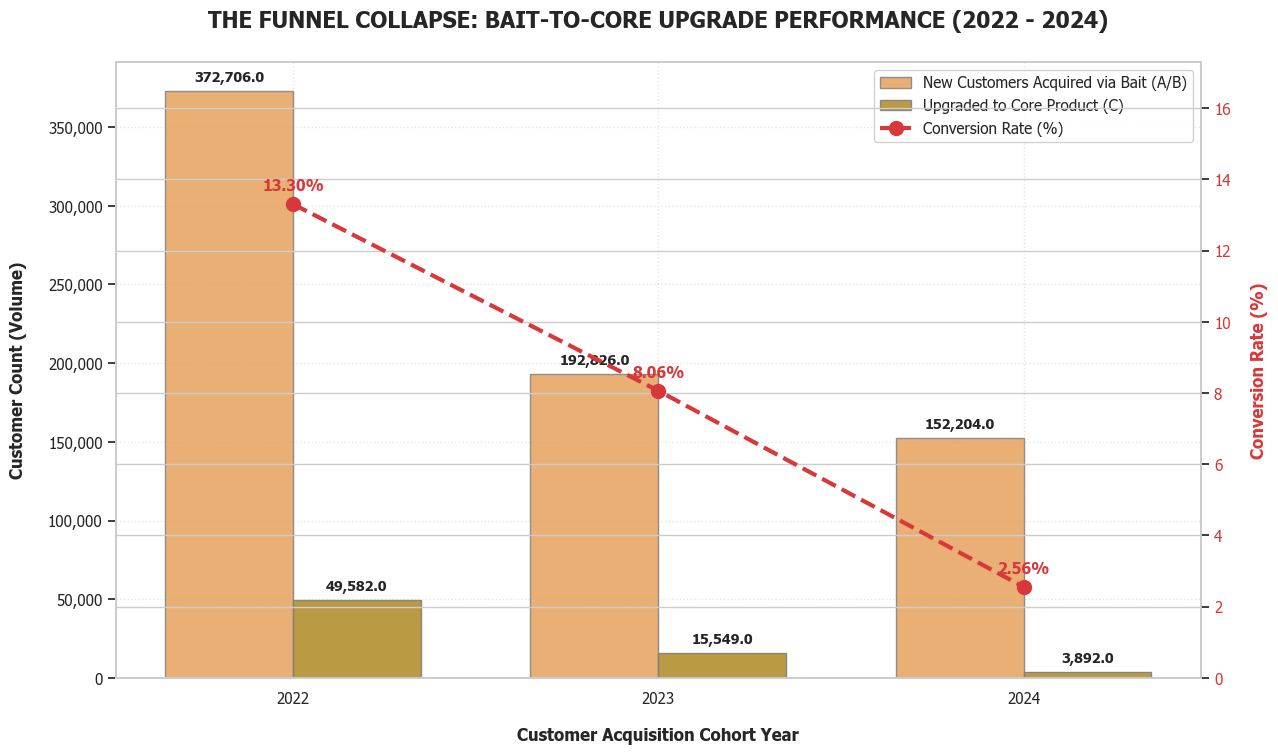

In [32]:
# Create assets directory if running from notebooks/ or root
assets_dir = '../assets/charts/'
if not os.path.exists('../assets/'):
    assets_dir = 'assets/charts/'
os.makedirs(assets_dir, exist_ok=True)

# Prepare data for plotting
plot_data = funnel_conversion_summary.copy()
years_str = plot_data['acquisition_year'].astype(str)

# Initialize the figure and the first axis (ax1)
fig, ax1 = plt.subplots(figsize=(14, 8))

# Define spacing and bar widths
width = 0.35
x_indices = np.arange(len(years_str))

# Plot Volume Bars (Bait acquired vs Converted)
bar1 = ax1.bar(x_indices - width/2, plot_data['bait_acquired_customer_count'], width, 
               label='New Customers Acquired via Bait (A/B)', color='#E6A15C', edgecolor='grey', alpha=0.85)
bar2 = ax1.bar(x_indices + width/2, plot_data['successfully_converted_count'], width, 
               label='Upgraded to Core Product (C)', color='#B38F2D', edgecolor='grey', alpha=0.9)

# Customize ax1 (Volume Axis)
ax1.set_xlabel('Customer Acquisition Cohort Year', fontsize=12, fontweight='bold', labelpad=15)
ax1.set_ylabel('Customer Count (Volume)', fontsize=12, fontweight='bold', labelpad=15)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(years_str, fontsize=11)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# Add value labels on top of the bars
ax1.bar_label(bar1, fmt='{:,}', padding=5, fontsize=10, fontweight='bold')
ax1.bar_label(bar2, fmt='{:,}', padding=5, fontsize=10, fontweight='bold')

# Create the second axis (ax2) sharing the same x-axis
ax2 = ax1.twinx()

# Plot the Conversion Rate line
line = ax2.plot(x_indices, plot_data['conversion_rate (%)'], color='#D9383A', marker='o', 
                markersize=10, linewidth=3, linestyle='--', label='Conversion Rate (%)')

# Customize ax2 (Percentage Axis)
ax2.set_ylabel('Conversion Rate (%)', color='#D9383A', fontsize=12, fontweight='bold', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#D9383A')
ax2.set_ylim(0, max(plot_data['conversion_rate (%)']) * 1.3) # Add padding for labels

# Add percentage labels along the line plot
for i, txt in enumerate(plot_data['conversion_rate (%)']):
    ax2.annotate(f"{txt:.2f}%", (x_indices[i], plot_data['conversion_rate (%)'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', 
                 color='#D9383A', fontsize=11, fontweight='bold')

# Combine legends from both axes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

plt.title('THE FUNNEL COLLAPSE: BAIT-TO-CORE UPGRADE PERFORMANCE (2022 - 2024)', 
          fontsize=16, fontweight='bold', pad=25)

# Save high-resolution chart
output_chart_path = os.path.join(assets_dir, 'bait_funnel_conversion.png')
plt.savefig(output_chart_path, dpi=300, bbox_inches='tight')
print(f"Polished funnel chart successfully exported to: '{output_chart_path}'")

plt.show()

**ITB's loss-leader strategy has completely failed.**

- **Top-of-funnel shrinkage:** The number of new customers attracted by loss-leader products (A/B) has free-fallen from **372,706 (2022)** to just **152,204 (2024)** (a decline of over 59%).

- **Middle-of-funnel leakage:** The actual conversion rate from customers who bought A/B to those who bought C has collapsed uncontrollably from **13.30% (2022)** to a mere **2.56% (2024)**.

This means that for every 100 new customers who purchased product A/B in 2024, only about 2–3 went on to purchase product C. The conversion engine has ceased to function effectively.

## 4. The Leaky Bucket Crisis: Customer Retention & Cohort Diagnostics

Acquiring a customer is only half the battle; keeping them engaged dictates long-term business survival. At ITB, while the front-end marketing "mouth" was pumping in hundreds of thousands of users, the back-end "bucket" was heavily leaking.

In this section, we diagnose this crisis using two industry-standard methodologies:
1.  **Overall 90-day Churn Rate:** A customer is classified as "churned" if their last purchase occurred more than 90 days before the final operational snapshot date of our database.
2.  **Quarterly Cohort Retention Heatmap:** We segment customers into temporal cohorts based on the quarter of their first purchase. We then track the percentage of unique active customers returning to purchase in subsequent quarters (Quarter 0 to Quarter 11). This visualizes exactly when and how fast customers are abandoning ITB.

*The completed heatmap will be exported directly to `assets/charts/`.*

=== 1. Calculating Overall 90-day Churn Rate ===
Operational Snapshot Date: 2024-12-31
90-day Churn Threshold Date: 2024-10-02
Total Unique Historical Customers: 780,272
Active Customers (Purchased within last 90 days): 116,963 (14.99%)
Churned Customers (No purchase in last 90 days): 663,309 (85.01%)

=== 2. Generating Quarterly Cohort Retention Matrix ===
Cohort Retention Matrix successfully calculated.

=== 3. Visualizing Cohort Retention Heatmap ===
Cohort Heatmap successfully exported to: '../assets/charts/cohort_retention_heatmap.png'


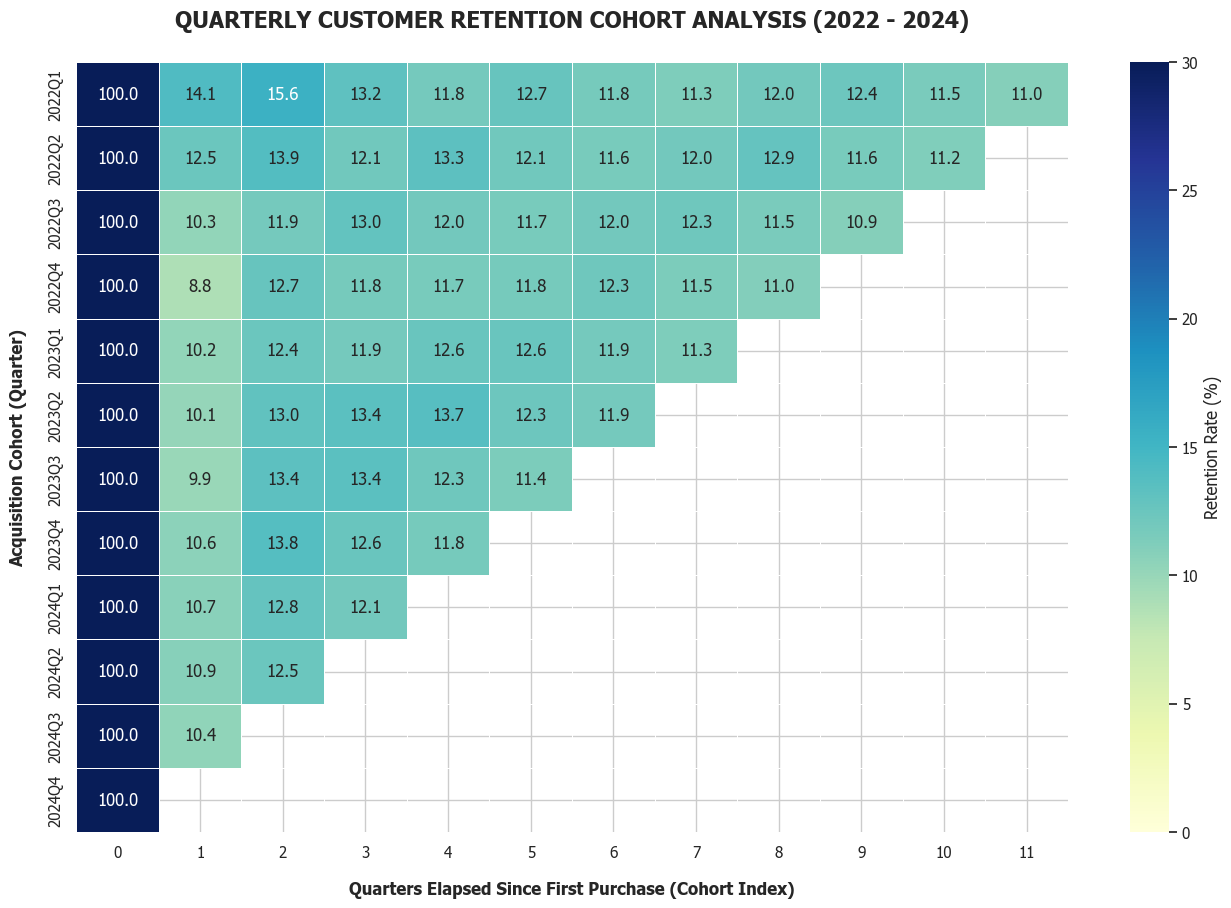

In [33]:
from datetime import timedelta

print("=== 1. Calculating Overall 90-day Churn Rate ===")

# Establish the snapshot date (1 day after the latest recorded transaction)
snapshot_date = df_delivered['order_date'].max() + timedelta(days=1)
# Calculate the threshold date for 90 days churn
churn_threshold_date = snapshot_date - timedelta(days=90)

# Identify the latest purchase date for each unique customer
df_last_purchase = df_delivered.groupby('customer_id')['order_date'].max().reset_index()
df_last_purchase.rename(columns={'order_date': 'last_purchase_date'}, inplace=True)

# Mark as churned if their last transaction is older than the threshold date
df_last_purchase['is_churned'] = df_last_purchase['last_purchase_date'] < churn_threshold_date
total_customers = len(df_last_purchase)
churned_customers = df_last_purchase['is_churned'].sum()
overall_churn_rate = (churned_customers / total_customers) * 100

print(f"Operational Snapshot Date: {snapshot_date.strftime('%Y-%m-%d')}")
print(f"90-day Churn Threshold Date: {churn_threshold_date.strftime('%Y-%m-%d')}")
print(f"Total Unique Historical Customers: {total_customers:,}")
print(f"Active Customers (Purchased within last 90 days): {total_customers - churned_customers:,} ({(100 - overall_churn_rate):.2f}%)")
print(f"Churned Customers (No purchase in last 90 days): {churned_customers:,} ({overall_churn_rate:.2f}%)")


print("\n=== 2. Generating Quarterly Cohort Retention Matrix ===")

# Create customer cohort base
df_cohort_base = df_delivered[['customer_id', 'order_date']].copy()
df_cohort_base['order_quarter'] = df_cohort_base['order_date'].dt.to_period('Q')

# Map each transaction to the customer's first purchase quarter (Acquisition Quarter)
df_customer_cohorts = df_first_purchases[['customer_id', 'first_purchase_date']].copy()
df_customer_cohorts['first_purchase_quarter'] = df_customer_cohorts['first_purchase_date'].dt.to_period('Q')

df_cohort_merged = pd.merge(df_cohort_base, df_customer_cohorts[['customer_id', 'first_purchase_quarter']], on='customer_id', how='left')

# Calculate Cohort Index (the difference in quarters between order quarter and acquisition quarter)
df_cohort_merged['cohort_index'] = (df_cohort_merged['order_quarter'] - df_cohort_merged['first_purchase_quarter']).apply(lambda x: x.n)

# Group and aggregate unique customers per cohort and cohort index
cohort_group = df_cohort_merged.groupby(['first_purchase_quarter', 'cohort_index'])['customer_id'].nunique().reset_index()

# Pivot to create the cohort matrix
cohort_pivot = cohort_group.pivot(index='first_purchase_quarter', columns='cohort_index', values='customer_id')

# Extract Cohort Sizes (the active customer count in Quarter 0)
cohort_sizes = cohort_pivot.iloc[:, 0]

# Calculate Retention Rate percentages
retention_matrix = cohort_pivot.div(cohort_sizes, axis=0) * 100

print("Cohort Retention Matrix successfully calculated.")


print("\n=== 3. Visualizing Cohort Retention Heatmap ===")

# Set up plotting style
plt.figure(figsize=(16, 10))

# Format index strings for clean y-axis labels
retention_matrix.index = retention_matrix.index.astype(str)

# Plot the heatmap using Seaborn
ax_heatmap = sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f', # Display percentages with 1 decimal place
    cmap='YlGnBu',
    vmin=0,
    vmax=30, # Cap max color threshold at 30% to highlight the steep drops clearly
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    linecolor='white'
)

# Customize axis labels and titles
plt.title('QUARTERLY CUSTOMER RETENTION COHORT ANALYSIS (2022 - 2024)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Quarters Elapsed Since First Purchase (Cohort Index)', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Acquisition Cohort (Quarter)', fontsize=12, fontweight='bold', labelpad=15)

# Save high-resolution chart
output_heatmap_path = os.path.join(assets_dir, 'cohort_retention_heatmap.png')
plt.savefig(output_heatmap_path, dpi=300, bbox_inches='tight')
print(f"Cohort Heatmap successfully exported to: '{output_heatmap_path}'")

plt.show()

- The absolute dark green (100.0%) in column 0 indicates that all new customers joined in that quarter.

- Immediately upon moving to column 1 (the second quarter after purchase), the color instantly shifts to pale/yellowish. The retention rate **plummets vertically to 8.8% - 14.1%**.

- This means that **86% - 91% of customers have completely disappeared** and never return to make another purchase right after their first quarter. ITB's bucket is severely leaking from the bottom.

## 5. Customer Profiling & RFM Segmentation for Core Product C

To recover from the acquisition and retention crisis, ITB must shift its strategy from low-value, mass-market acquisition to high-value, direct engagement. To support this pivot, we must profile and quantify the actual value of our core customers.

In this section, we segment ITB's unique customers into two strategic groups:
1. **Bought Product C:** Customers who have purchased our premium core Product C at least once.
2. **Others:** Customers who have only purchased the low-cost bait Products A & B.

We apply the **RFM (Recency, Frequency, Monetary) Framework** to evaluate and compare these segments:
*   **Recency (R):** Average days since the customer's last transaction (lower is better, indicating active engagement).
*   **Frequency (F):** Average number of successful historical transactions (higher is better).
*   **Monetary (M):** Average total spending in VND (higher is better, representing total customer value).

*The generated comparative RFM bar charts will be saved to `assets/charts/rfm_comparison.png`.*

--- 1. Computing RFM Metrics per Customer ---

RFM Comparative Summary (Segment Averages):


,customer_segment,recency,frequency,monetary
0,Bought Product C,314.6 Days,3.33 Orders,"90,530,016 VND"
1,Others,469.5 Days,1.93 Orders,"17,063,374 VND"



--- 2. Visualizing RFM Comparative Analysis ---
RFM comparison chart successfully exported to: '../assets/charts/rfm_comparison.png'


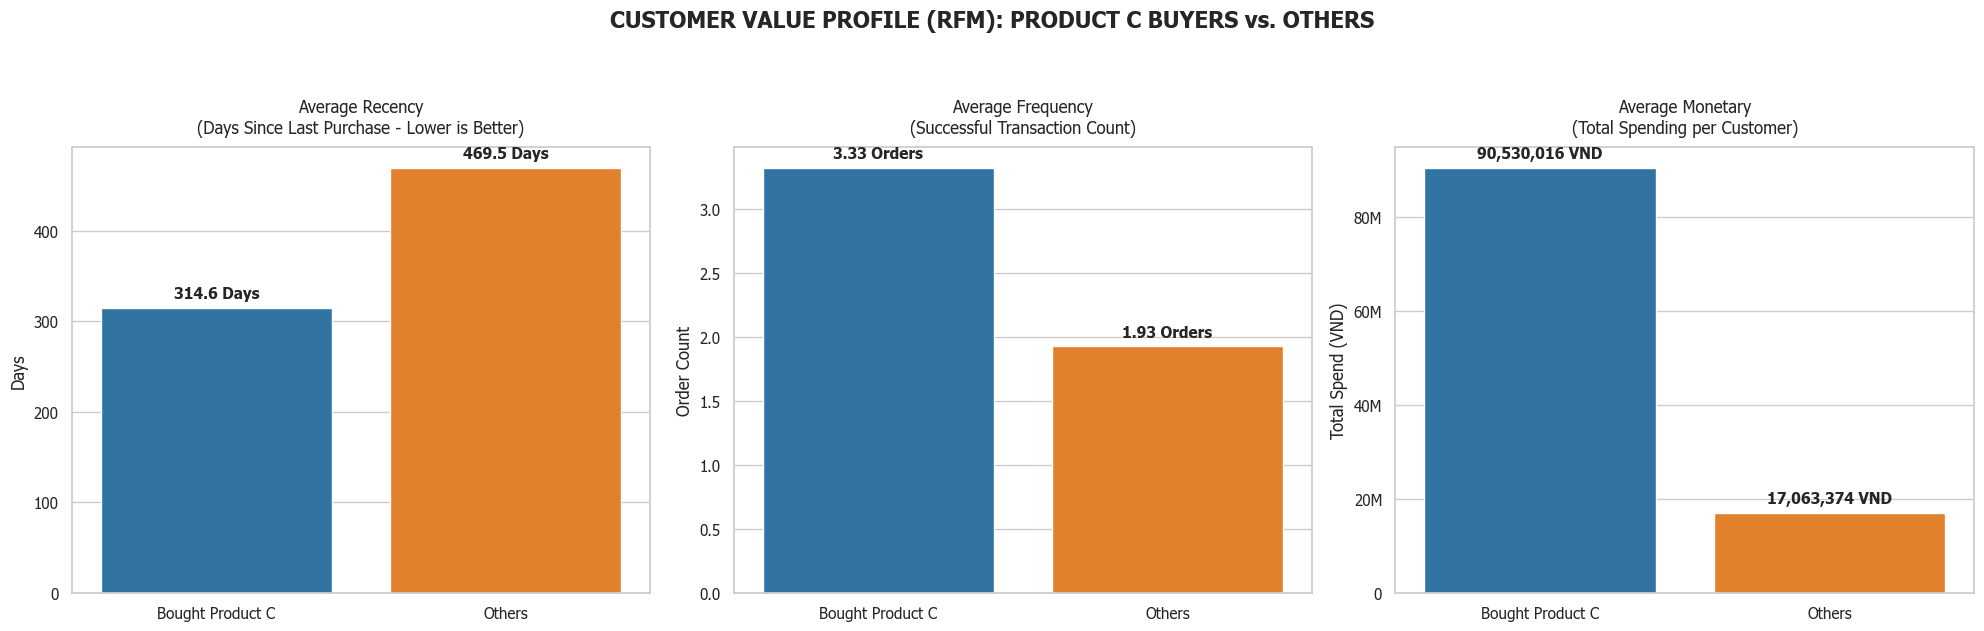

In [34]:
print("--- 1. Computing RFM Metrics per Customer ---")

# Calculate RFM metrics at the customer level
# Recency: Days elapsed from last purchase to the snapshot date
# Frequency: Count of unique successful orders
# Monetary: Sum of product_price across successful transactions
df_rfm = df_delivered.groupby('customer_id').agg(
    recency=('order_date', lambda date: (snapshot_date - date.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('product_price', 'sum')
).reset_index()

# Step 2: Segment customers based on whether they bought Product C
customers_who_bought_c = set(df_delivered[df_delivered['product_profile'] == 'product_C']['customer_id'].unique())

df_rfm['customer_segment'] = np.where(
    df_rfm['customer_id'].isin(customers_who_bought_c),
    'Bought Product C',
    'Others'
)

# Step 3: Compute RFM averages across segments
rfm_summary = df_rfm.groupby('customer_segment')[['recency', 'frequency', 'monetary']].mean().reset_index()

print("\nRFM Comparative Summary (Segment Averages):")
display(rfm_summary.style.format({
    'recency': '{:.1f} Days',
    'frequency': '{:.2f} Orders',
    'monetary': '{:,.0f} VND'
}))


print("\n--- 2. Visualizing RFM Comparative Analysis ---")

# Setup 1x3 side-by-side bar plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CUSTOMER VALUE PROFILE (RFM): PRODUCT C BUYERS vs. OTHERS', fontsize=16, fontweight='bold', y=1.05)

palette_colors = {'Bought Product C': '#1F77B4', 'Others': '#FF7F0E'}

# Plot 1: Recency Comparison (Lower is better)
sns.barplot(data=rfm_summary, x='customer_segment', y='recency', ax=axes[0], palette=palette_colors, hue='customer_segment', legend=False)
axes[0].set_title('Average Recency\n(Days Since Last Purchase - Lower is Better)', fontsize=12, pad=10)
axes[0].set_ylabel('Days')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f} Days", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Plot 2: Frequency Comparison (Higher is better)
sns.barplot(data=rfm_summary, x='customer_segment', y='frequency', ax=axes[1], palette=palette_colors, hue='customer_segment', legend=False)
axes[1].set_title('Average Frequency\n(Successful Transaction Count)', fontsize=12, pad=10)
axes[1].set_ylabel('Order Count')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f} Orders", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Plot 3: Monetary Comparison (Higher is better)
sns.barplot(data=rfm_summary, x='customer_segment', y='monetary', ax=axes[2], palette=palette_colors, hue='customer_segment', legend=False)
axes[2].set_title('Average Monetary\n(Total Spending per Customer)', fontsize=12, pad=10)
axes[2].set_ylabel('Total Spend (VND)')
axes[2].set_xlabel('')
axes[2].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6)) if x >= 1e6 else "{:,}".format(int(x))))
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():,.0f} VND", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()

# Save high-resolution chart
output_rfm_path = os.path.join(assets_dir, 'rfm_comparison.png')
plt.savefig(output_rfm_path, dpi=300, bbox_inches='tight')
print(f"RFM comparison chart successfully exported to: '{output_rfm_path}'")

plt.show()

1. **Recency (R):** The group that purchases product C has an average time between purchases of **314.6 days**, which is **155 days** (nearly 5 months) faster than the other group. This demonstrates that they have significantly higher engagement and loyalty.

2. **Frequency (F):** The C group purchases an average of **3.33 orders**, nearly double the other group **(1.93 orders)**.

3. **Monetary (M) – Extreme paradox:** The group that purchases product C has an average spend of up to **90,530,016 VND per customer**, while the remaining group spends only **17,063,374 VND**. The C group's spending value is **5.3 times higher than the regular customer base!**

*Key insight:* The customer group that buys product C is truly the "gold mine" providing long-term sustainable value for ITB. The strategy of focusing resources to directly reach and build loyalty programs to retain this customer segment (instead of using a cheap loss-leader funnel) is completely validated by the data.

## 6. Channel Performance & Operational Cost Structure Diagnostics

ITB distributes its products across four channels, incurring different cost structures. Historically, the management assumed that the heavy operational costs of physical channels (Store and Premium) were justified because they delivered higher volume and served as brand experience hubs.

In this section, we build a comprehensive financial model to calculate the exact profitability of each channel for 2022, 2023, and 2024:
1.  **Variable Costs Calculation:** We apply distinct variable cost rules (commissions, platform fees, transport, taxes, and product-specific installation fees) to each transaction.
2.  **Fixed Costs Allocation:**
    *   `ecommerce`: Fixed at **7.0 Billion VND / year**.
    *   `website`: Fixed at **16.9 Billion VND / year** (incorporating Design, CS staff, Office rent, Storage, and other administrative overheads).
    *   `stores` & `premium`: Share a retail sales staff budget of **838.656 Billion VND / year** (8,736 sales staff at 8M VND/month). In accordance with ITB's accounting logic, this shared fixed cost is allocated annually between the Stores and Premium channels based on their revenue ratio.
3.  **Profitability Comparison:** We calculate the Net Profit and **Net Profit Margin (%)** for each channel over time to evaluate which channels are true profit engines and which are cost burdens.

*The comparative margin chart will be exported to `assets/charts/channel_performance_margin.png`.*

--- 1. Computing Variable & Fixed Costs dynamically ---

Channel Profitability & Cost Efficiency Table:


,year,sales_channel,total_revenue,total_contribution_margin,allocated_fixed_cost,net_profit,net_profit_margin (%)
0,2022,ecommerce,"1,894,464,223,443 VND","1,403,278,356,507 VND","7,000,000,000 VND","1,396,278,356,507 VND",73.70%
1,2022,premium,"1,083,068,759,652 VND","774,808,349,423 VND","341,492,269,475 VND","433,316,079,948 VND",40.01%
2,2022,stores,"1,576,792,662,953 VND","1,290,213,104,397 VND","497,163,730,525 VND","793,049,373,872 VND",50.30%
3,2022,website,"2,659,647,466,333 VND","2,578,838,996,200 VND","16,900,000,000 VND","2,561,938,996,200 VND",96.33%
4,2023,ecommerce,"2,136,752,629,184 VND","1,572,684,720,054 VND","7,000,000,000 VND","1,565,684,720,054 VND",73.27%
5,2023,premium,"2,064,563,460,874 VND","1,468,528,885,474 VND","548,587,756,566 VND","919,941,128,908 VND",44.56%
6,2023,stores,"1,091,647,214,844 VND","883,466,939,581 VND","290,068,243,434 VND","593,398,696,147 VND",54.36%
7,2023,website,"1,804,226,154,866 VND","1,741,894,503,679 VND","16,900,000,000 VND","1,724,994,503,679 VND",95.61%
8,2024,ecommerce,"2,684,937,560,117 VND","1,964,868,596,578 VND","7,000,000,000 VND","1,957,868,596,578 VND",72.92%
9,2024,premium,"2,416,153,366,006 VND","1,713,960,048,584 VND","534,156,931,909 VND","1,179,803,116,675 VND",48.83%



--- 2. Visualizing Channel Profit Margin Trends ---

Channel performance chart successfully exported to: '../assets/charts/channel_performance_margin.png'


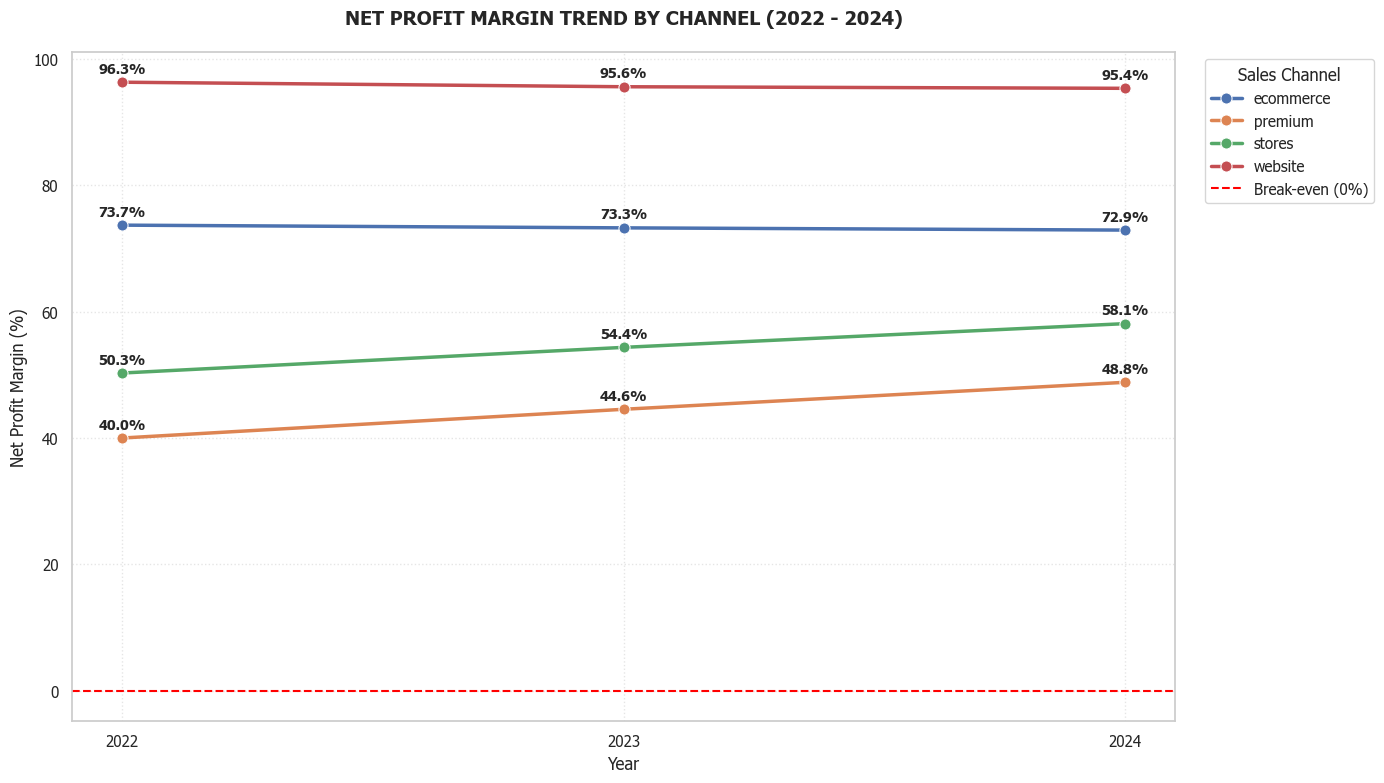

In [36]:
# Define the variable cost calculation function to ensure self-contained execution
def calculate_transaction_variable_costs(row):
    price = row['product_price']
    channel = row['sales_channel']
    product = row['product_profile']
    
    variable_cost = 0
    
    if channel == 'ecommerce':
        # 10% platform fee + 3% commission + 5% promotion + 5% tax = 23% of revenue
        variable_cost += 0.23 * price 
        variable_cost += 20000  # Shipping cost
        
    elif channel == 'website':
        variable_cost += 40000  # Shipping cost
        
    elif channel == 'stores':
        # 10% Partner Commission
        variable_cost += 0.10 * price
        # Sales Staff Commission
        if product == 'product_A':
            variable_cost += 0.03 * price
        elif product == 'product_B':
            variable_cost += 0.05 * price
        elif product == 'product_C':
            variable_cost += 0.10 * price
            
    elif channel == 'premium':
        # 10% Partner Commission
        variable_cost += 0.10 * price
        # Sales Staff Commission
        if product == 'product_C':
            variable_cost += 0.12 * price
        else: # Product A or B
            variable_cost += 0.03 * price

    # Product C installation fee (all channels)
    if product == 'product_C':
        variable_cost += 0.10 * price
            
    return variable_cost

print("--- 1. Computing Variable & Fixed Costs dynamically ---")

# Apply the variable cost function to successful delivered orders
df_delivered['variable_costs'] = df_delivered.apply(calculate_transaction_variable_costs, axis=1)
df_delivered['contribution_margin'] = df_delivered['product_price'] - df_delivered['variable_costs']

# Aggregate revenue and contribution margin by year and channel
channel_yearly = df_delivered.groupby(['year', 'sales_channel']).agg(
    total_revenue=('product_price', 'sum'),
    total_contribution_margin=('contribution_margin', 'sum')
).reset_index()

# Set up annual fixed cost rules
fixed_costs_config = {
    'ecommerce': 7_000_000_000,
    'website': 16_900_000_000,
    'physical_shared': 838_656_000_000 # Shared sales staff budget for stores & premium
}

# Calculate and allocate Fixed Costs for each row
allocated_fcs = []
for idx, row in channel_yearly.iterrows():
    year = row['year']
    channel = row['sales_channel']
    revenue = row['total_revenue']
    
    fc = 0
    if channel in ['ecommerce', 'website']:
        fc = fixed_costs_config[channel]
    elif channel in ['stores', 'premium']:
        # Calculate shared revenue ratio for stores and premium in this specific year
        shared_mask = (channel_yearly['year'] == year) & (channel_yearly['sales_channel'].isin(['stores', 'premium']))
        total_shared_revenue = channel_yearly.loc[shared_mask, 'total_revenue'].sum()
        
        if total_shared_revenue > 0:
            channel_ratio = revenue / total_shared_revenue
            fc = fixed_costs_config['physical_shared'] * channel_ratio
            
    allocated_fcs.append(fc)

channel_yearly['allocated_fixed_cost'] = allocated_fcs

# Step 3: Compute Net Profit & Net Profit Margin (%)
channel_yearly['net_profit'] = channel_yearly['total_contribution_margin'] - channel_yearly['allocated_fixed_cost']
channel_yearly['net_profit_margin (%)'] = (channel_yearly['net_profit'] / channel_yearly['total_revenue']) * 100

print("\nChannel Profitability & Cost Efficiency Table:")
display(channel_yearly.style.format({
    'total_revenue': '{:,.0f} VND',
    'total_contribution_margin': '{:,.0f} VND',
    'allocated_fixed_cost': '{:,.0f} VND',
    'net_profit': '{:,.0f} VND',
    'net_profit_margin (%)': '{:.2f}%'
}))


print("\n--- 2. Visualizing Channel Profit Margin Trends ---")

# Plot Net Profit Margin Trends
plt.figure(figsize=(14, 8))
ax_line = sns.lineplot(
    data=channel_yearly, 
    x='year', 
    y='net_profit_margin (%)', 
    hue='sales_channel', 
    marker='o', 
    linewidth=2.5,
    markersize=8
)

plt.axhline(0, color='red', linestyle='--', lw=1.5, label='Break-even (0%)')
plt.title('NET PROFIT MARGIN TREND BY CHANNEL (2022 - 2024)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Profit Margin (%)', fontsize=12)
plt.legend(title='Sales Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(channel_yearly['year'].unique())
plt.grid(True, which='both', linestyle=':', alpha=0.5)

# Add values along the lines
for idx, row in channel_yearly.iterrows():
    ax_line.text(row['year'], row['net_profit_margin (%)'] + 1.5, f"{row['net_profit_margin (%)']:.1f}%", 
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save high-resolution chart
output_margin_path = os.path.join(assets_dir, 'channel_performance_margin.png')
plt.savefig(output_margin_path, dpi=300, bbox_inches='tight')
print(f"\nChannel performance chart successfully exported to: '{output_margin_path}'")

plt.show()

- **Website Channel**: Extremely impressive profit margin, maintaining stability at ~95.4% - 96.3% across the years. This channel has virtually no variable costs (no affiliate commissions, no service fees) and extremely lean fixed costs.

- **Ecommerce Channel**: Very strong profit margin, stable at ~72.9% - 73.7%.

- **Stores & Premium Channels (Physical)**: The lowest profit margins in the system, reaching only 58.1% and 48.8% respectively in 2024. The core reason is the burden of **allocated fixed costs** - Stores bear over **304 billion VND**, Premium bears over **534 billion VND** in 2024 alone (primarily from sales staff salaries).

## 7. Strategic "What-If" Financial Simulation Scenarios (2024 Baseline)

To provide the Board of Directors with concrete, data-backed strategic recommendations, we build a financial simulation engine using our latest completed fiscal year (**2024**) as the baseline. 

We model three progressive optimization scenarios:

1.  **Scenario 1: Tactical Commission Optimization (Hoa hồng đại lý)**
    *   *Logic:* Renegotiate commission contracts with physical retail partners and sales agents to cut Stores commission by **15%** and Premium commission by **10%**.
    *   *Tactical Lever:* Increases net profit margins immediately without restructuring the retail footprint.

2.  **Scenario 2: Operational Footprint Streamlining (Tinh gọn định phí)**
    *   *Logic:* Audit physical store performance to shut down bottom-performing outlets and optimize staffing, leading to a **20% reduction** in physical channel allocated fixed costs (saving 20% of the shared sales staff budget).
    *   *Operational Lever:* Targets the largest cost driver of physical retail.

3.  **Scenario 3: Strategic Capital Reallocation (Dịch chuyển đầu tư & Tăng trưởng trực tuyến)**
    *   *Logic:* Close down the most inefficient Stores to save **30% of the Stores fixed cost budget** (saving ~91.3 Billion VND). Reinvest 100% of these savings directly into digital marketing (SEO, SEM, CRM) for our highest-margin channel: **Website**.
    *   *Strategic Lever:* Assuming a conservative Digital Return on Ad Spend (**ROAS**) of **5:1**, this reallocated budget generates new Website revenue, which flows directly into Website's **95.36%** net profit margin. This models a true transition from "empty growth" to "profitable digital scale".

In [38]:
print("--- 1. Initializing 2024 Baseline Variables ---")

# Isolate successful transactions from the year 2024
df_2024 = df_delivered[df_delivered['year'] == 2024].copy()

# Calculate baseline metrics
original_net_profit_2024 = channel_yearly[channel_yearly['year'] == 2024]['net_profit'].sum()

# Helper function to compute commission for Stores channel
def get_stores_commission(row):
    price = row['product_price']
    product = row['product_profile']
    # 10% Partner Commission + Staff Commission (3% for A, 5% for B, 10% for C)
    staff_rate = 0.03 if product == 'product_A' else (0.05 if product == 'product_B' else 0.10)
    return price * (0.10 + staff_rate)

# Helper function to compute commission for Premium channel
def get_premium_commission(row):
    price = row['product_price']
    product = row['product_profile']
    # 10% Partner Commission + Staff Commission (12% for C, 3% for others)
    staff_rate = 0.12 if product == 'product_C' else 0.03
    return price * (0.10 + staff_rate)

# Dynamically calculate baseline physical commissions in 2024
df_stores_2024 = df_2024[df_2024['sales_channel'] == 'stores']
baseline_comm_stores = df_stores_2024.apply(get_stores_commission, axis=1).sum()

df_premium_2024 = df_2024[df_2024['sales_channel'] == 'premium']
baseline_comm_premium = df_premium_2024.apply(get_premium_commission, axis=1).sum()

# Extract baseline physical fixed costs in 2024
baseline_fc_stores = channel_yearly[(channel_yearly['year'] == 2024) & (channel_yearly['sales_channel'] == 'stores')]['allocated_fixed_cost'].sum()
baseline_fc_premium = channel_yearly[(channel_yearly['year'] == 2024) & (channel_yearly['sales_channel'] == 'premium')]['allocated_fixed_cost'].sum()

# Extract Website Net Profit Margin in 2024
website_margin_2024 = channel_yearly[(channel_yearly['year'] == 2024) & (channel_yearly['sales_channel'] == 'website')]['net_profit_margin (%)'].iloc[0] / 100

print(f"Baseline Net Profit 2024: {original_net_profit_2024:,.0f} VND")
print(f"Baseline Stores Commission: {baseline_comm_stores:,.0f} VND")
print(f"Baseline Premium Commission: {baseline_comm_premium:,.0f} VND")
print(f"Baseline Stores Fixed Cost: {baseline_fc_stores:,.0f} VND")
print(f"Baseline Premium Fixed Cost: {baseline_fc_premium:,.0f} VND")


print("\n--- 2. Simulating Scenario 1: Commission Optimization ---")
savings_s1_stores = baseline_comm_stores * 0.15
savings_s1_premium = baseline_comm_premium * 0.10
total_savings_s1 = savings_s1_stores + savings_s1_premium
profit_s1 = original_net_profit_2024 + total_savings_s1
growth_s1 = (total_savings_s1 / original_net_profit_2024) * 100

print(f"Scenario 1 Total Savings: +{total_savings_s1:,.0f} VND ({growth_s1:.2f}% Profit Growth)")


print("\n--- 3. Simulating Scenario 2: Operational Footprint Streamlining ---")
total_physical_fc_2024 = baseline_fc_stores + baseline_fc_premium
total_savings_s2 = total_physical_fc_2024 * 0.20
profit_s2 = original_net_profit_2024 + total_savings_s2
growth_s2 = (total_savings_s2 / original_net_profit_2024) * 100

print(f"Scenario 2 Total Savings: +{total_savings_s2:,.0f} VND ({growth_s2:.2f}% Profit Growth)")


print("\n--- 4. Simulating Scenario 3: Strategic Capital Reallocation ---")
# Budget shifted from Stores Fixed Cost (30%)
budget_shifted = baseline_fc_stores * 0.30

# Profit gained directly from cost cutting
profit_from_cutting = budget_shifted

# Revenue generated on Website using ROAS 5:1
new_website_revenue = budget_shifted * 5

# Net Profit generated from new Website revenue
new_website_net_profit = new_website_revenue * website_margin_2024

# Net impact of Scenario 3 (Budget Shifted + New Net Profit)
net_impact_s3 = profit_from_cutting + new_website_net_profit
profit_s3 = original_net_profit_2024 + net_impact_s3
growth_s3 = (net_impact_s3 / original_net_profit_2024) * 100

print(f"Scenario 3 Budget Shifted: {budget_shifted:,.0f} VND")
print(f"Scenario 3 Projected New Website Revenue: {new_website_revenue:,.0f} VND")
print(f"Scenario 3 Total Net Impact: +{net_impact_s3:,.0f} VND ({growth_s3:.2f}% Profit Growth)")


print("\n=== 5. Consolidating Simulation Results ===")

# Build simulation summary dataframe
sim_results = pd.DataFrame({
    'Scenario': [
        'Baseline (Actual 2024)',
        'Scenario 1: Commission Optimization (Stores -15%, Premium -10%)',
        'Scenario 2: Operational Streamlining (Physical FC -20%)',
        'Scenario 3: Capital Reallocation (Stores FC -30% -> Website Marketing at ROAS 5:1)'
    ],
    'Net Profit (VND)': [
        original_net_profit_2024,
        profit_s1,
        profit_s2,
        profit_s3
    ],
    'Net Savings/Growth (VND)': [
        0,
        total_savings_s1,
        total_savings_s2,
        net_impact_s3
    ],
    'Profit Increase (%)': [
        0.0,
        growth_s1,
        growth_s2,
        growth_s3
    ]
})

display(sim_results.style.format({
    'Net Profit (VND)': '{:,.0f} VND',
    'Net Savings/Growth (VND)': '{:,.0f} VND',
    'Profit Increase (%)': '{:.2f}%'
}))

--- 1. Initializing 2024 Baseline Variables ---
Baseline Net Profit 2024: 6,101,067,066,645 VND
Baseline Stores Commission: 218,628,046,546 VND
Baseline Premium Commission: 497,933,643,821 VND
Baseline Stores Fixed Cost: 304,499,068,091 VND
Baseline Premium Fixed Cost: 534,156,931,909 VND

--- 2. Simulating Scenario 1: Commission Optimization ---
Scenario 1 Total Savings: +82,587,571,364 VND (1.35% Profit Growth)

--- 3. Simulating Scenario 2: Operational Footprint Streamlining ---
Scenario 2 Total Savings: +167,731,200,000 VND (2.75% Profit Growth)

--- 4. Simulating Scenario 3: Strategic Capital Reallocation ---
Scenario 3 Budget Shifted: 91,349,720,427 VND
Scenario 3 Projected New Website Revenue: 456,748,602,136 VND
Scenario 3 Total Net Impact: +526,901,767,931 VND (8.64% Profit Growth)

=== 5. Consolidating Simulation Results ===


,Scenario,Net Profit (VND),Net Savings/Growth (VND),Profit Increase (%)
0,Baseline (Actual 2024),"6,101,067,066,645 VND",0 VND,0.00%
1,"Scenario 1: Commission Optimization (Stores -15%, Premium -10%)","6,183,654,638,009 VND","82,587,571,364 VND",1.35%
2,Scenario 2: Operational Streamlining (Physical FC -20%),"6,268,798,266,645 VND","167,731,200,000 VND",2.75%
3,Scenario 3: Capital Reallocation (Stores FC -30% -> Website Marketing at ROAS 5:1),"6,627,968,834,576 VND","526,901,767,931 VND",8.64%


# Quick Insight Analysis from the Scenario Table:

- **Scenario 1 (Optimize affiliate commissions):** Delivers only a modest profit increase of **1.35%** (saving over 82 billion VND). This is a good short-term technical measure, but it does not address the root cause of channel fixed costs.

- **Scenario 2 (Streamline 20% of fixed costs on retail space/staff):** Delivers a better increase of **2.75%** (saving over 167 billion VND). This measure is twice as effective as renegotiating commissions.

- **Scenario 3 (Strategic shift – Close underperforming Stores, reinvest into Website with a 5:1 ROAS):** This is the "golden key" that drives ITB's net profit to break out most strongly, reaching **8.64%** (generating an additional **526.9 billion VND** in new net profit).

  - *Why does this scenario win decisively?* Because instead of merely cutting costs passively (Scenario 2), this scenario takes idle capital from an underperforming area (Stores – 58% profit margin) and proactively reinvests it into the highest-performing cash-printing engine in the system (Website – 95% profit margin).